## import library

In [ ]:
import os
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import kagglehub

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 64
EPOCHS = 13

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


## read and download of data

In [ ]:
print("[INFO] Downloading dataset via KaggleHub...")
base_path = kagglehub.dataset_download("rameezakther/mrl-eye-open-or-close-dataset")
print(f"[INFO] Dataset Path: {base_path}")



[INFO] Downloading dataset via KaggleHub...
Using Colab cache for faster access to the 'mrl-eye-open-or-close-dataset' dataset.
[INFO] Dataset Path: /kaggle/input/mrl-eye-open-or-close-dataset


In [ ]:
dataset_root = os.path.join(base_path, "mrl_dataset")
train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")

In [ ]:

SAVE_DIR = pathlib.Path("./saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

## (Data Pipelines)

In [ ]:
print("[INFO] Loading datasets into memory pipeline...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='grayscale',
    shuffle=True,
    seed=SEED
)


[INFO] Loading datasets into memory pipeline...
Found 20000 files belonging to 2 classes.


In [ ]:

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

Found 1000 files belonging to 2 classes.


In [ ]:


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## model architecture

In [ ]:
def build_eye_state_classifier(input_shape=(64, 64, 1)):
    inputs = layers.Input(shape=input_shape, name="eye_input")

    x = layers.Rescaling(1.0 / 255.0, name="rescaling")(inputs)

    x = layers.RandomRotation(factor=0.08)(x)
    x = layers.RandomZoom(height_factor=0.08)(x)

    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid', name="eye_output")(x)

    return models.Model(inputs=inputs, outputs=outputs, name="EyeStateClassifier")

model = build_eye_state_classifier()
model.summary()

Model: "EyeStateClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eye_input (InputLayer)          │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ eye_output (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,665 (397.13 KB)

 Trainable params: 101,217 (395.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)



## callback

In [ ]:
best_keras_model_path = os.path.join(SAVE_DIR, "best_eye_model.keras")

model_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=best_keras_model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

## train model

In [ ]:
print("[INFO] Starting training session...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=model_callbacks
)

[INFO] Starting training session...
Epoch 1/13
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.6510 - loss: 0.6123 - precision: 0.6553 - recall: 0.6206
Epoch 1: val_loss improved from None to 2.09666, saving model to saved_models/best_eye_model.keras

Epoch 1: finished saving model to saved_models/best_eye_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 179s 462ms/step - accuracy: 0.7056 - loss: 0.5504 - precision: 0.7169 - recall: 0.6795 - val_accuracy: 0.5000 - val_loss: 2.0967 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/13
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8519 - loss: 0.3514 - precision: 0.8687 - recall: 0.8316
Epoch 2: val_loss did not improve from 2.09666
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 457ms/step - accuracy: 0.8718 - loss: 0.3120 - precision: 0.8854 - recall: 0.8542 - val_accuracy: 0.5100 - val_loss: 2.7792 - val_precision: 1.0000 - val_recall: 0.0200 - learning_rate: 0.0010
Epoch 3/13
313/313 ━━━━━━━━━━━━━━━━━━

## visualization

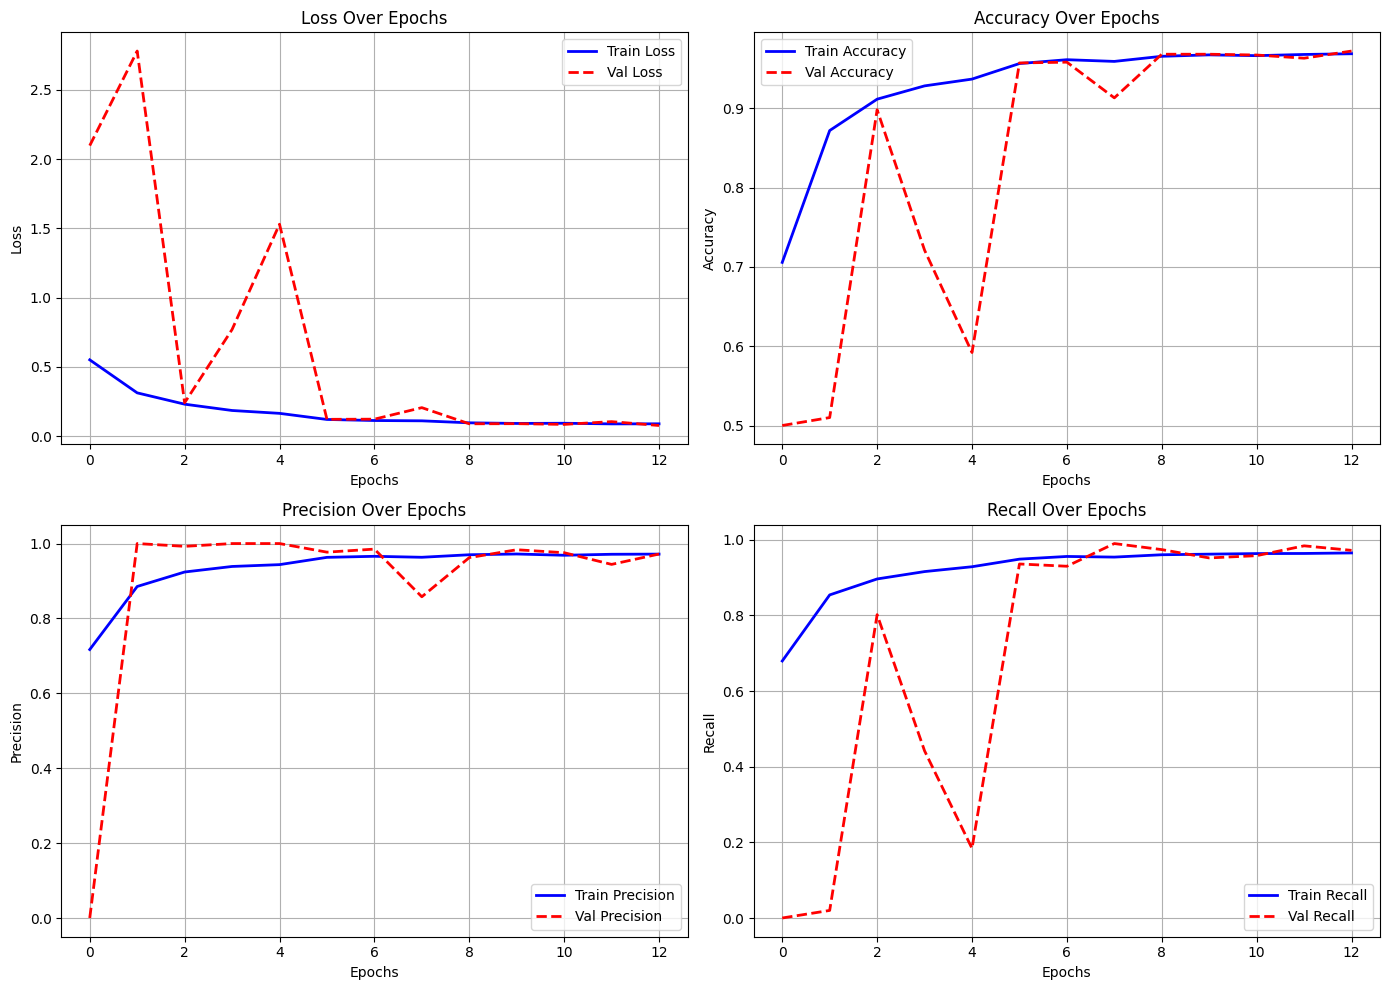

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Loss Curve
    axes[0, 0].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('Loss Over Epochs')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # 2. Accuracy Curve
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title('Accuracy Over Epochs')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # 3. Precision Curve
    axes[1, 0].plot(history.history['precision'], label='Train Precision', color='blue', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_title('Precision Over Epochs')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # 4. Recall Curve
    axes[1, 1].plot(history.history['recall'], label='Train Recall', color='blue', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_title('Recall Over Epochs')
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## save models

In [ ]:
print("[INFO] Loading best checkpoint for export...")
best_model = tf.keras.models.load_model(best_keras_model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_bytes = converter.convert()

tflite_path = os.path.join(SAVE_DIR, "eye_model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model_bytes)

print(f"[SUCCESS] Saved Keras Model:  {best_keras_model_path}")
print(f"[SUCCESS] Saved TFLite Model: {tflite_path}")

[INFO] Loading best checkpoint for export...
Saved artifact at '/tmp/tmpj9l38eeh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='eye_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136296915559888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915560848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915560656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915560272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915561424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915558928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915561040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915561232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915559504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136296915562384: TensorSpec(shape=(), dtype=

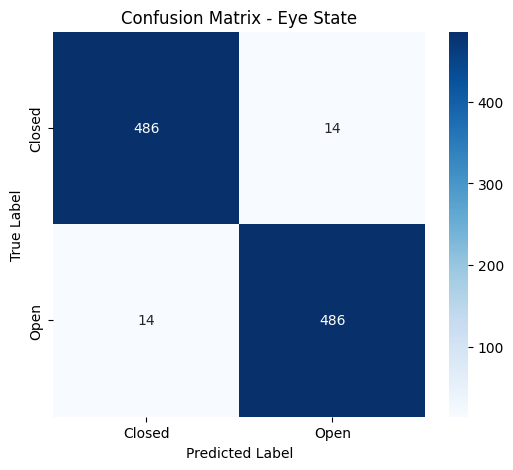


Classification Report:

              precision    recall  f1-score   support

      Closed       0.97      0.97      0.97       500
        Open       0.97      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Closed', 'Open'],
            yticklabels=['Closed', 'Open'])
plt.title('Confusion Matrix - Eye State')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Closed', 'Open']))

## show result test

[INFO] Loading best saved model from ./saved_models/best_eye_model.keras...
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.9720 - loss: 0.0764 - precision: 0.9720 - recall: 0.9720

================ TEST RESULTS ================
Test Loss:      0.0764
Test Accuracy:  97.20%
Test Precision: 97.20%
Test Recall:    97.20%

Detailed Classification Report:

              precision    recall  f1-score   support

      Closed       0.97      0.97      0.97       500
        Open       0.97      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



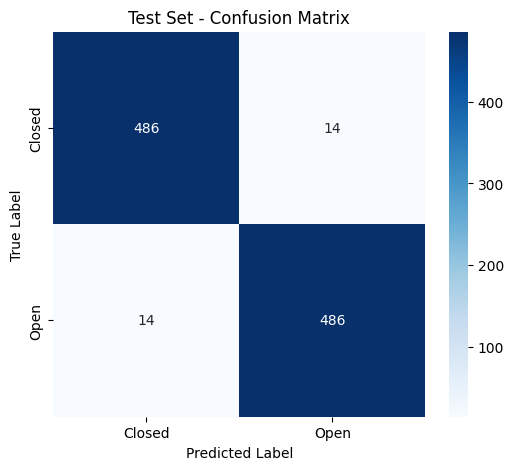

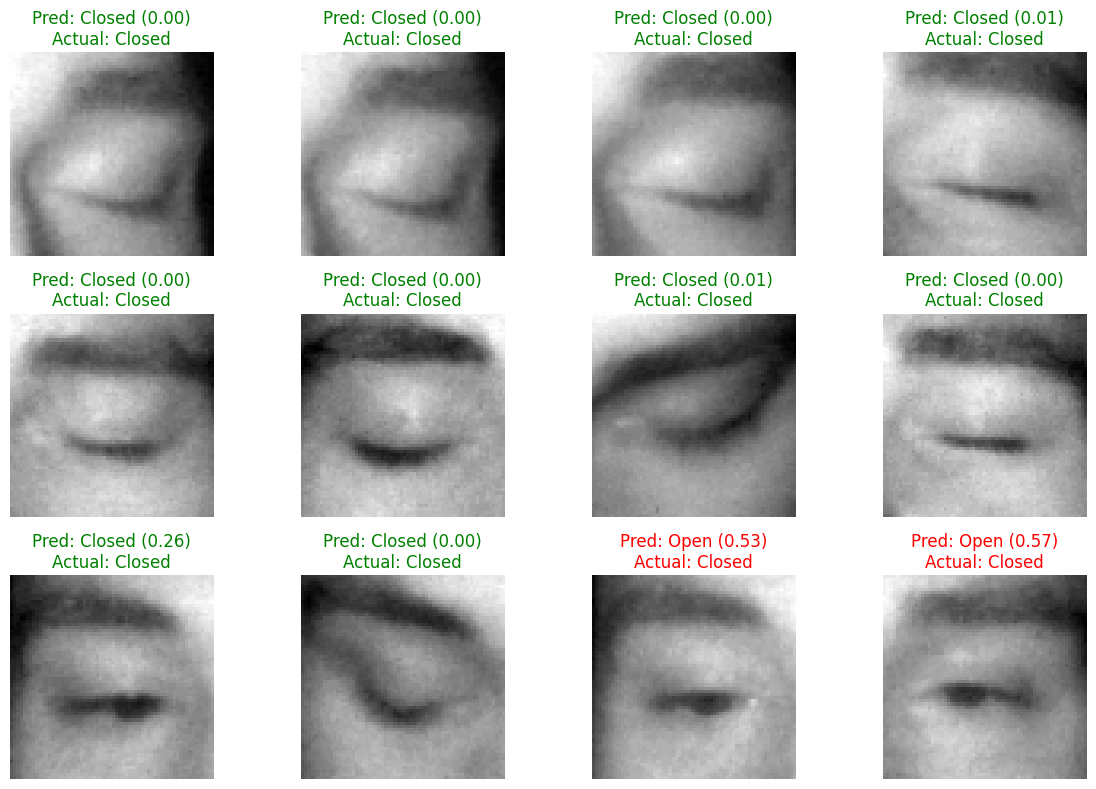

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. تحميل الموديل المحفوظ المحسن
best_model_path = "./saved_models/best_eye_model.keras"
print(f"[INFO] Loading best saved model from {best_model_path}...")
model = tf.keras.models.load_model(best_model_path)

# 2. تقييم الموديل الكلي على val_ds (Test Data)
results = model.evaluate(val_ds, verbose=1)
print(f"\n================ TEST RESULTS ================")
print(f"Test Loss:      {results[0]:.4f}")
print(f"Test Accuracy:  {results[1]*100:.2f}%")
print(f"Test Precision: {results[2]*100:.2f}%")
print(f"Test Recall:    {results[3]*100:.2f}%")
print(f"==============================================\n")

y_true = []
y_pred = []
y_probs = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    preds = (probs > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds.flatten())
    y_probs.extend(probs.flatten())

class_names = ['Closed', 'Open']
print("Detailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test Set - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(12, 8))
for images, labels in val_ds.take(1):
    probs = model.predict(images, verbose=0)
    for i in range(12): # عرض أول 12 صورة
        ax = plt.subplot(3, 4, i + 1)
        img = images[i].numpy().astype("uint8")
        actual_label = class_names[int(labels[i])]
        pred_prob = probs[i][0]
        pred_label = "Open" if pred_prob > 0.5 else "Closed"

        color = 'green' if pred_label == actual_label else 'red'

        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Pred: {pred_label} ({pred_prob:.2f})\nActual: {actual_label}", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()